In [1]:
import scanpy as sc
from sklearn.metrics import adjusted_rand_score as ari

In [2]:
#read h5ad file
adata = sc.read_h5ad("Ma2019_Liver-Biliary_ENN_Balanced.h5ad")

In [3]:
#normalize data
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

C:\Users\Arman\AppData\Local\Programs\Python\Python311\Lib\site-packages\legacy_api_wrap\__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
C:\Users\Arman\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\preprocessing\_simple.py:392: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


## Error handling

#### There is no VAR balanced data here, which was giving an error and we corrected it.

In [4]:

adata = sc.read_h5ad("Ma2019_Liver-Biliary_ENN_Balanced.h5ad")

print("=== ADATA ===")
print(adata)

print("\n=== OBS COLUMNS ===")
print(adata.obs.columns)

print("\n=== VAR COLUMNS ===")
print(adata.var.columns)

print("\n=== SHAPE ===")
print(adata.shape)

if "sample" in adata.obs.columns:
    print("\n=== SAMPLE VALUE COUNTS ===")
    print(adata.obs["sample"].value_counts(dropna=False).head(20))

    print("\n=== SAMPLE NA COUNT ===")
    print(adata.obs["sample"].isna().sum())
else:
    print("\nNO 'sample' COLUMN FOUND")

print("\n=== X TYPE ===")
print(type(adata.X))

print("\n=== X SAMPLE ===")
print(adata.X[:5, :5])

try:
    print("\n=== NA IN X ===")
    print(np.isnan(adata.X).sum())
except:
    print("NaN check failed (likely sparse matrix)")

=== ADATA ===
AnnData object with n_obs × n_vars = 2463 × 17505
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'cell_type', 'complexity', 'umap1', 'umap2', 'g1s_score', 'g2m_score', 'cell_cycle_phase', 'mp_top_score', 'mp_top', 'mp_assignment', 'disease', 'nCount_tmp', 'nFeature_tmp', 'percent.ribo', 'percent.mito', 'log10GenesPerUmi', 'ident'
    layers: 'logcounts'

=== OBS COLUMNS ===
Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'cell_type',
       'complexity', 'umap1', 'umap2', 'g1s_score', 'g2m_score',
       'cell_cycle_phase', 'mp_top_score', 'mp_top', 'mp_assignment',
       'disease', 'nCount_tmp', 'nFeature_tmp', 'percent.ribo', 'percent.mito',
       'log10GenesPerUmi', 'ident'],
      dtype='object')

=== VAR COLUMNS ===
Index([], dtype='object')

=== SHAPE ===
(2463, 17505)

=== SAMPLE VALUE COUNTS ===
sample
H38    890
C46    476
H65    428
C66    237
C26    214
C56     88
C25     76
H37     54
Name: count, dtype: int64

=== SAMPLE NA COUN

In [5]:
import scanpy as sc

adata_bal = sc.read_h5ad("Ma2019_Liver-Biliary_ENN_Balanced.h5ad")
adata_raw = sc.read_h5ad("Ma2019_Liver-Biliary.h5ad")

adata_bal.var = adata_raw.var.copy()
adata_bal.var_names = adata_raw.var_names.copy()

adata_bal.var_names_make_unique()

sc.pp.highly_variable_genes(
    adata_bal,
    n_top_genes=2000,
    batch_key="sample",
    flavor="cell_ranger"
)

sc.tl.pca(adata_bal)
sc.pp.neighbors(adata_bal)
sc.tl.umap(adata_bal)

adata_bal

AnnData object with n_obs × n_vars = 2463 × 17505
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'cell_type', 'complexity', 'umap1', 'umap2', 'g1s_score', 'g2m_score', 'cell_cycle_phase', 'mp_top_score', 'mp_top', 'mp_assignment', 'disease', 'nCount_tmp', 'nFeature_tmp', 'percent.ribo', 'percent.mito', 'log10GenesPerUmi', 'ident'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'logcounts'
    obsp: 'distances', 'connectivities'

In [6]:
adata = sc.read_h5ad("Ma2019_Liver-Biliary_ENN_Balanced.h5ad")

print("=== ADATA ===")
print(adata)

print("\n=== OBS COLUMNS ===")
print(adata.obs.columns)

print("\n=== VAR COLUMNS ===")
print(adata.var.columns)

print("\n=== SHAPE ===")
print(adata.shape)

if "sample" in adata.obs.columns:
    print("\n=== SAMPLE VALUE COUNTS ===")
    print(adata.obs["sample"].value_counts(dropna=False).head(20))

    print("\n=== SAMPLE NA COUNT ===")
    print(adata.obs["sample"].isna().sum())
else:
    print("\nNO 'sample' COLUMN FOUND")

print("\n=== X TYPE ===")
print(type(adata.X))

print("\n=== X SAMPLE ===")
print(adata.X[:5, :5])

try:
    print("\n=== NA IN X ===")
    print(np.isnan(adata.X).sum())
except:
    print("NaN check failed (likely sparse matrix)")

=== ADATA ===
AnnData object with n_obs × n_vars = 2463 × 17505
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'cell_type', 'complexity', 'umap1', 'umap2', 'g1s_score', 'g2m_score', 'cell_cycle_phase', 'mp_top_score', 'mp_top', 'mp_assignment', 'disease', 'nCount_tmp', 'nFeature_tmp', 'percent.ribo', 'percent.mito', 'log10GenesPerUmi', 'ident'
    layers: 'logcounts'

=== OBS COLUMNS ===
Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'cell_type',
       'complexity', 'umap1', 'umap2', 'g1s_score', 'g2m_score',
       'cell_cycle_phase', 'mp_top_score', 'mp_top', 'mp_assignment',
       'disease', 'nCount_tmp', 'nFeature_tmp', 'percent.ribo', 'percent.mito',
       'log10GenesPerUmi', 'ident'],
      dtype='object')

=== VAR COLUMNS ===
Index([], dtype='object')

=== SHAPE ===
(2463, 17505)

=== SAMPLE VALUE COUNTS ===
sample
H38    890
C46    476
H65    428
C66    237
C26    214
C56     88
C25     76
H37     54
Name: count, dtype: int64

=== SAMPLE NA COUN

In [7]:
adata_bal.shape[1] == adata_raw.shape[1]

True

# Done

# -------------------------------------------

In [8]:
#feature selection and dimensionality reduction
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

C:\Users\Arman\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:309: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
C:\Users\Arman\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:309: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
C:\Users\Arman\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:309: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
C:\Users\Arman\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:309: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
C:\Users\Arman\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:309: RuntimeWarning: invalid value encountered i

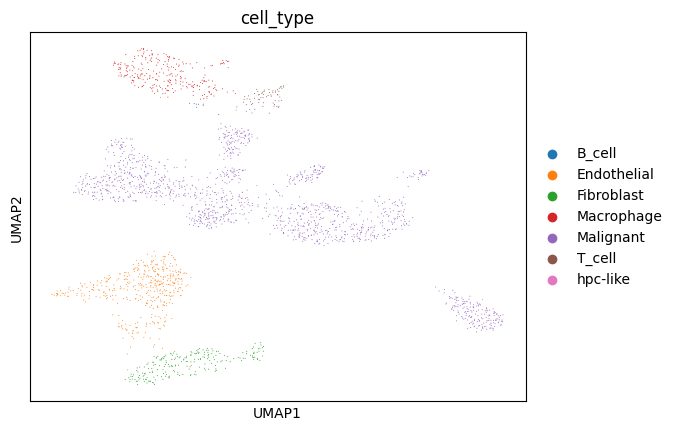

In [9]:
#visualize umap
sc.pl.umap(
    adata,
    color="cell_type",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

Clustering

In [10]:
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

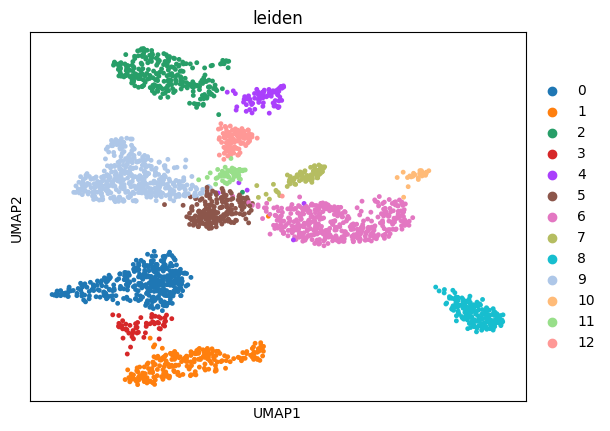

In [11]:
sc.pl.umap(adata, color=["leiden"])

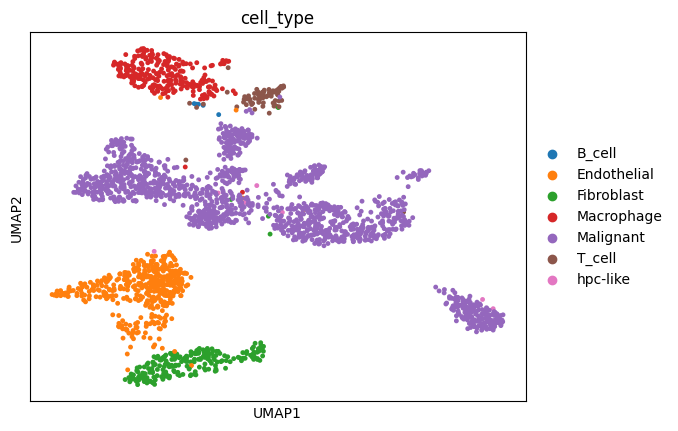

In [12]:
sc.pl.umap(adata, color=["cell_type"])

Marker gene identification

In [13]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

C:\Users\Arman\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\Arman\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\Arman\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\Arman\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\Arman\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: inv

In [14]:
markers_df = sc.get.rank_genes_groups_df(adata, group=None)

In [15]:
import pandas as pd

In [16]:
B_cell_markers = markers_df[markers_df["group"] == "2"]
endothelial_cell_markers = markers_df[markers_df["group"] == "0"]
Fibroblast_cell_markers = markers_df[markers_df["group"] == "1"]
Macrophage_cell_markers = markers_df[markers_df["group"] == "2"]
Maliganat_cell_markers = pd.concat([markers_df[markers_df["group"] == g] for g in ["8", "10", "6", "7", "5", "9", "12"]])
hpc_cell_markers = markers_df[markers_df["group"] == "6"]

In [17]:
print(f"B_cell_markers: {list(B_cell_markers.head(20)['names'])}")
print(f"endothelial_cell_markers: {list(endothelial_cell_markers.head(20)['names'])}")
print(f"Fibroblast_cell_markers: {list(Fibroblast_cell_markers.head(20)['names'])}")
print(f"Macrophage_cell_markers: {list(Macrophage_cell_markers.head(20)['names'])}")
print(f"Maliganat_cell_markers: {list(Maliganat_cell_markers.head(20)['names'])}")
print(f"hpc_cell_markers: {list(hpc_cell_markers.head(20)['names'])}")

B_cell_markers: ['HLA-DRA', 'CD74', 'HLA-DPB1', 'AIF1', 'HLA-DRB1', 'HLA-DPA1', 'TYROBP', 'FCER1G', 'SRGN', 'LAPTM5', 'HLA-DQB1', 'LST1', 'HLA-DMA', 'CST3', 'TMSB4X', 'CYBA', 'NPC2', 'PLAUR', 'CTSS', 'HLA-DRB5']
endothelial_cell_markers: ['RAMP2', 'GNG11', 'HLA-E', 'HSPG2', 'ENG', 'EMCN', 'PLVAP', 'TCF4', 'PECAM1', 'CLEC14A', 'EGFL7', 'PLPP1', 'A2M', 'RNASE1', 'RAMP3', 'FKBP1A', 'EPAS1', 'VAMP5', 'ECSCR', 'ID1']
Fibroblast_cell_markers: ['CALD1', 'BGN', 'MYL9', 'TAGLN', 'TPM2', 'ACTA2', 'TPM1', 'PPP1R14A', 'IGFBP7', 'MFGE8', 'FRZB', 'SPARC', 'PLAC9', 'MYLK', 'SPARCL1', 'DSTN', 'SEPTIN4', 'MAP1B', 'NDUFA4L2', 'PGF']
Macrophage_cell_markers: ['HLA-DRA', 'CD74', 'HLA-DPB1', 'AIF1', 'HLA-DRB1', 'HLA-DPA1', 'TYROBP', 'FCER1G', 'SRGN', 'LAPTM5', 'HLA-DQB1', 'LST1', 'HLA-DMA', 'CST3', 'TMSB4X', 'CYBA', 'NPC2', 'PLAUR', 'CTSS', 'HLA-DRB5']
Maliganat_cell_markers: ['RBP4', 'HRG', 'TTR', 'KNG1', 'AGXT', 'ANG', 'ANGPTL3', 'HPX', 'SERPINC1', 'APOB', 'ALDOB', 'A1BG', 'APOC3', 'C2', 'AMBP', 'AZGP1',

Calculate Adjusted Rand Index for clustering labels and true annotations

In [18]:
ari(adata.obs["cell_type"], adata.obs["leiden"])

0.3092005425330239